# subseq_hunt — motif x context interactions via k-SII
Each annotated motif is a player, plus one **context** player (variable-region positions under no motif).
Necessity (KO) game: absent players' positions are dinuc-shuffled (n_rep reps, averaged); present kept WT.
Score = K562 pred. **Full-order k-SII** decomposes the prediction into main effects (order 1) and
higher-order interactions (order 2, 3, ...) so you can see how first and higher orders interact.
Kernel: **Hippo_agft_venv** (shapiq 1.4.1 + K562 encoder).

In [1]:
# setup: K562 model, seqs from swap_seqs.npz, motif spans+names from situate edits.csv
import sys, itertools, collections, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from pathlib import Path
sys.path.insert(0, "/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/"
                   "Hippo_dependency_chromatin-accessibility/alphagenome-encoder-ft/src")
from tangermeme.utils import one_hot_encode
from tangermeme.ersatz import dinucleotide_shuffle
from alphagenome_encoder_ft import EncoderMPRAModel
import shapiq

ADAPTER = 15                                        # var region = insert[15:215]
SIT = Path("/grid/koo/home/pmantill/projects/situate/data")
Z = np.load("/grid/koo/home/pmantill/projects/SEAM_validate/context_feat/flex/data/swap_seqs.npz")
wt_str, names = Z["wt"], Z["names"]
high, low = Z["high"].tolist(), Z["low"].tolist()

CKPT = "/grid/koo/home/shared/models/alphagenome_encoder/torch/mpra_K562/finetuned_encoder.pt"
model = EncoderMPRAModel.from_checkpoint(CKPT, device="cuda").eval()
cfg = torch.load(CKPT, map_location="cpu", weights_only=False)["construct_config"]
suffix = one_hot_encode(cfg["promoter_seq"] + cfg["barcode_seq"]).float()   # (4,51) promoter+barcode

@torch.no_grad()
def score(ohe):                                     # (B,4,230) -> (B,) K562 pred
    out = []
    for k in range(0, len(ohe), 512):
        b = ohe[k:k + 512]
        x = torch.cat([b, suffix.expand(len(b), -1, -1)], 2)
        out.append(model(x.transpose(1, 2).cuda()).cpu().numpy())
    return np.concatenate(out)

# motifs per seq — pull LIVE from situate/edits.csv (SEAM:K562:<peak> keys, updated in situate); the rep
# seqs are not in the live SEAM session so fall back to the June mcs_k562 dump. coords var-region [0,200) -> +ADAPTER.
LIVE = pd.read_csv("/grid/koo/home/pmantill/projects/situate/edits.csv")
DUMP = pd.read_csv(SIT / "annotations/mcs_k562/edits.csv")
peak_name = {0: "peak26256", 1: "peak84030", 2: "peak27535_Reversed"}
def motifs_for(i):
    if i in peak_name:
        g = LIVE[LIVE.sequence_name == f"SEAM:K562:{peak_name[i]}:foreground_scaled"]
    else:
        g = DUMP[DUMP.sequence_name == i]
    return [(int(s) + ADAPTER, int(e) + ADAPTER, m) for m, s, e in zip(g.motif_name, g.start, g.end)]
motifs = {i: motifs_for(i) for i in sorted(set(high) | set(low))}
motifs = {i: v for i, v in motifs.items() if v}                 # keep only annotated seqs
seqs = sorted(motifs)
print(len(seqs), "annotated seqs:", [f"{names[i]}({len(motifs[i])})" for i in seqs])

12 annotated seqs: ['peak26256 100_k200(2)', 'peak84030 300_k300(1)', 'peak27535_Reversed 100_k300(4)', 'rep K562:492(4)', 'rep K562:314(6)', 'rep K562:465(7)', 'rep K562:349(5)', 'rep K562:311(4)', 'rep K562:443(4)', 'rep K562:593(2)', 'rep K562:456(4)', 'rep K562:468(5)']


In [2]:
# per-seq FULL-order k-SII: players = motifs + context; necessity (KO) coalition values -> ExactComputer.
# order = n_players, so every interaction order (1..n) is returned. context = last player.
N_REP = 30

class PrecomputedGame(shapiq.Game):
    def __init__(self, n, empty, cval):
        self.cval = cval
        super().__init__(n_players=n, normalization_value=empty)
    def value_function(self, coalitions):
        return np.array([self.cval[tuple(int(b) for b in row)] for row in coalitions])

def seq_sii(i):
    wt = one_hot_encode(str(wt_str[i])).float()                     # (4,230)
    spans = motifs[i]
    player_names = [m for _, _, m in spans] + ["context"]
    masks = [np.zeros(230, bool) for _ in spans]
    for m, (s, e, _) in zip(masks, spans):
        m[s:e] = True
    ctx = np.zeros(230, bool); ctx[ADAPTER:ADAPTER + 200] = True     # context = var region minus motifs
    for m in masks:
        ctx &= ~m
    players = masks + [ctx]
    n = len(players)
    shuf = dinucleotide_shuffle(wt.unsqueeze(0), n=N_REP, random_state=0)[0]   # (N_REP,4,230)
    coals = list(itertools.product([0, 1], repeat=n))
    blocks = []
    for coal in coals:
        x = wt.unsqueeze(0).repeat(N_REP, 1, 1).clone()
        for present, mask in zip(coal, players):
            if not present:
                x[:, :, mask] = shuf[:, :, mask]                     # KO absent player -> shuffle
        blocks.append(x)
    preds = score(torch.cat(blocks, 0)).reshape(len(coals), N_REP).mean(1)   # marginalize reps
    cval = {coal: float(v) for coal, v in zip(coals, preds)}
    game = PrecomputedGame(n, cval[tuple([0] * n)], cval)
    sii = shapiq.ExactComputer(n_players=n, game=game)(index="k-SII", order=n)   # full order
    return sii, spans, player_names

results = {}
for i in seqs:
    results[i] = seq_sii(i)
    print(f"{names[i]}: done ({len(motifs[i])} motifs + context)")

peak26256 100_k200: done (2 motifs + context)
peak84030 300_k300: done (1 motifs + context)
peak27535_Reversed 100_k300: done (4 motifs + context)
rep K562:492: done (4 motifs + context)
rep K562:314: done (6 motifs + context)
rep K562:465: done (7 motifs + context)
rep K562:349: done (5 motifs + context)
rep K562:311: done (4 motifs + context)
rep K562:443: done (4 motifs + context)
rep K562:593: done (2 motifs + context)
rep K562:456: done (4 motifs + context)
rep K562:468: done (5 motifs + context)


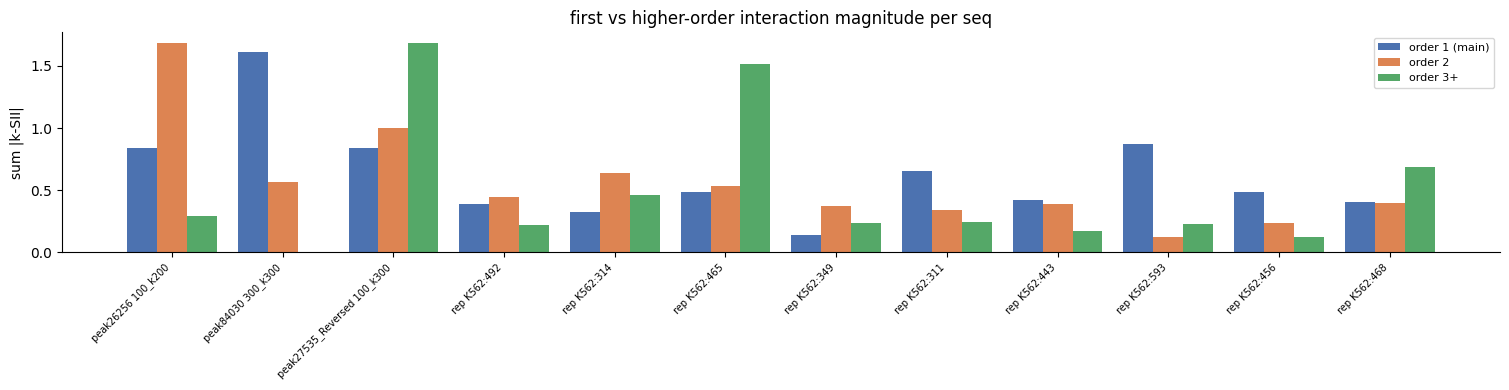

In [3]:
# PLOT 1 — first vs higher order across seqs: grouped bars of sum|k-SII| at order 1 / 2 / 3+, per seq.
# tall order-1 bar = mostly independent players; tall order 2/3+ = motifs & context act non-additively.
def omag(i, o, plus=False):
    dv = results[i][0].dict_values
    return sum(abs(v) for k, v in dv.items() if (len(k) >= o if plus else len(k) == o))
o1 = np.array([omag(i, 1) for i in seqs])
o2 = np.array([omag(i, 2) for i in seqs])
o3 = np.array([omag(i, 3, plus=True) for i in seqs])

x = np.arange(len(seqs)); w = 0.27
fig, ax = plt.subplots(figsize=(1.1 * len(seqs) + 2, 4))
ax.bar(x - w, o1, w, label="order 1 (main)", color="#4c72b0")
ax.bar(x,     o2, w, label="order 2", color="#dd8452")
ax.bar(x + w, o3, w, label="order 3+", color="#55a868")
ax.set_xticks(x); ax.set_xticklabels([names[i] for i in seqs], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("sum |k-SII|"); ax.set_title("first vs higher-order interaction magnitude per seq")
ax.legend(fontsize=8); ax.spines[["top", "right"]].set_visible(False); plt.tight_layout()

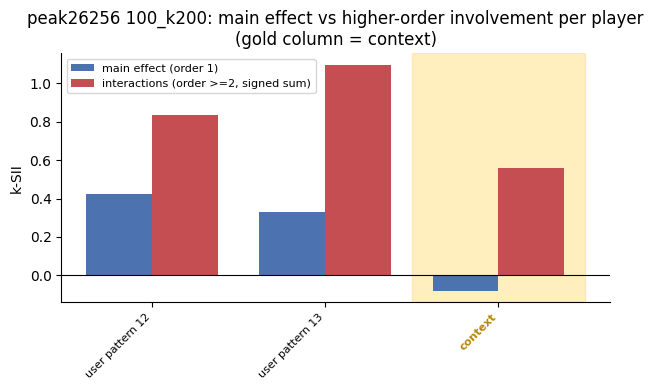

In [4]:
# PLOT 2 — per-player main effect vs interaction involvement (one seq). two bars per player:
#   main effect = order-1 k-SII;  interactions = signed sum of every order>=2 term containing that player.
# context bar tells you whether context works mostly alone (main) or through interactions with motifs.
SEL = seqs[0]                                                    # <- change to inspect another seq
sii, spans, pn = results[SEL]
n = len(pn)
main = np.array([sii.dict_values.get((j,), 0.0) for j in range(n)])
inter = np.array([sum(v for k, v in sii.dict_values.items() if len(k) >= 2 and j in k) for j in range(n)])

x = np.arange(n); w = 0.38
fig, ax = plt.subplots(figsize=(1.1 * n + 3, 4))
ax.axvspan(n - 1.5, n - 0.5, color="#ffe08a", alpha=0.55, zorder=0)   # highlight the context column
ax.bar(x - w / 2, main, w, label="main effect (order 1)", color="#4c72b0")
ax.bar(x + w / 2, inter, w, label="interactions (order >=2, signed sum)", color="#c44e52")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(pn, rotation=45, ha="right", fontsize=8)
lbl = ax.get_xticklabels()[-1]; lbl.set_fontweight("bold"); lbl.set_color("#b8860b")   # context tick
ax.set_ylabel("k-SII"); ax.set_title(f"{names[SEL]}: main effect vs higher-order involvement per player\n(gold column = context)")
ax.legend(fontsize=8); ax.spines[["top", "right"]].set_visible(False); plt.tight_layout()

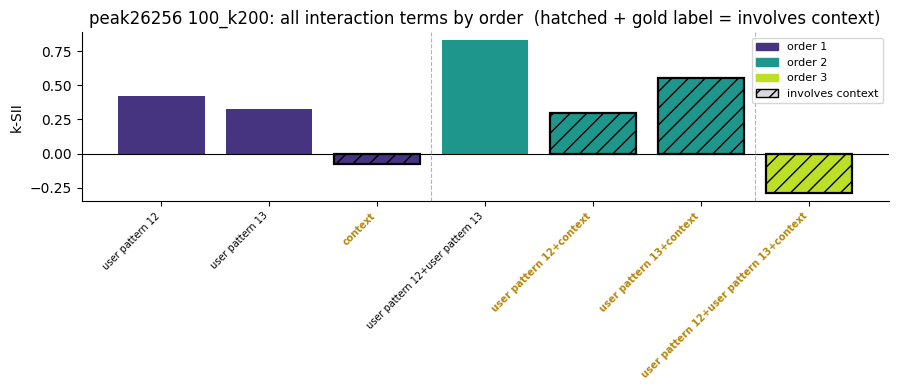

In [5]:
# PLOT 3 — every interaction term for one seq, grouped by order (bars). black edge = involves context.
# reads left-to-right: order-1 mains, then the pairwise motif<->context / motif<->motif terms, then triples.
sii, spans, pn = results[SEL]
terms = sorted(((k, v) for k, v in sii.dict_values.items() if len(k) >= 1),
               key=lambda kv: (len(kv[0]), kv[0]))
labels = ["+".join(pn[j] for j in k) for k, _ in terms]
vals = np.array([v for _, v in terms])
ordr = np.array([len(k) for k, _ in terms])
has_ctx = np.array([(n - 1) in k for k, _ in terms])
cmap = plt.cm.viridis(np.linspace(0.15, 0.9, ordr.max()))

fig, ax = plt.subplots(figsize=(1.0 * len(terms) + 2, 4))
xx = np.arange(len(terms))
bars = ax.bar(xx, vals, color=[cmap[o - 1] for o in ordr])
for b, c in zip(bars, has_ctx):                                 # context terms: thick black edge + hatch
    if c:
        b.set_edgecolor("k"); b.set_linewidth(1.6); b.set_hatch("//")
ax.axhline(0, color="k", lw=0.8)
for b in np.where(np.diff(ordr))[0]:                            # dashed separators between orders
    ax.axvline(b + 0.5, color="0.7", ls="--", lw=0.8)
ax.set_xticks(xx); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
for lab, c in zip(ax.get_xticklabels(), has_ctx):               # bold + gold labels for context terms
    if c:
        lab.set_color("#b8860b"); lab.set_fontweight("bold")
ax.set_ylabel("k-SII"); ax.set_title(f"{names[SEL]}: all interaction terms by order  (hatched + gold label = involves context)")
from matplotlib.patches import Patch
handles = [Patch(color=cmap[o - 1], label=f"order {o}") for o in range(1, ordr.max() + 1)]
handles.append(Patch(facecolor="0.85", edgecolor="k", hatch="//", label="involves context"))
ax.legend(handles=handles, fontsize=8); ax.spines[["top", "right"]].set_visible(False); plt.tight_layout()

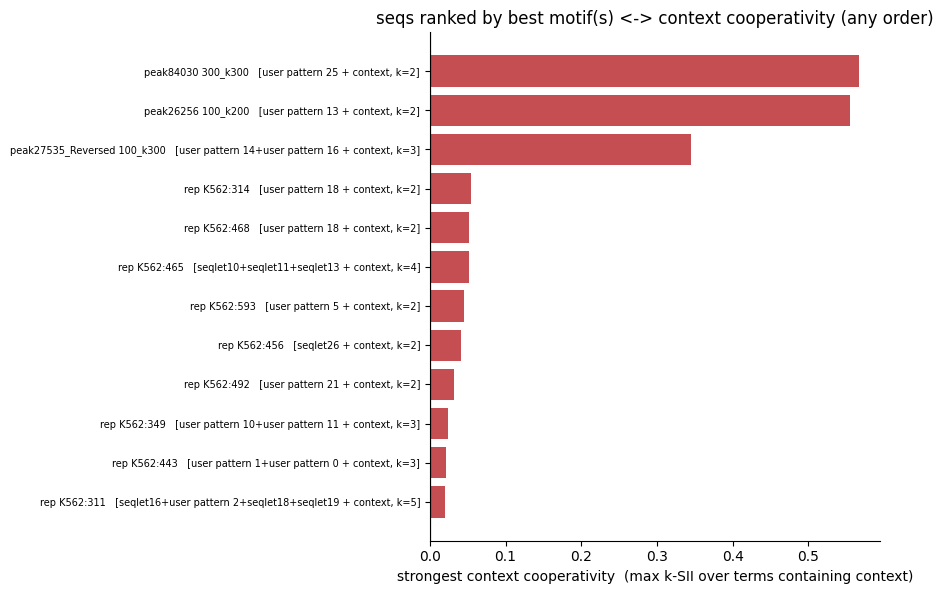

In [6]:
# PLOT 4 — rank seqs by STRONGEST context cooperativity at ANY order: for each seq take the max positive
# k-SII among all terms that CONTAIN the context player (order 2..n). the winning term (which motifs + which
# order k) is annotated, so a seq whose best coop is the full "all motifs + context" term still surfaces.
best = []
for i in seqs:
    sii, spans, pn = results[i]
    ci = len(pn) - 1
    ctx_terms = [(k, v) for k, v in sii.dict_values.items() if ci in k and len(k) >= 2]
    if not ctx_terms:
        continue
    key, val = max(ctx_terms, key=lambda kv: kv[1])                 # strongest cooperativity (max +k-SII)
    partners = "+".join(pn[j] for j in key if j != ci)
    best.append((names[i], val, partners, len(key)))
best.sort(key=lambda r: r[1])

y = np.arange(len(best))
fig, ax = plt.subplots(figsize=(9, 0.42 * len(best) + 1))
ax.barh(y, [b[1] for b in best], color=["#c44e52" if b[1] > 0 else "#4c72b0" for b in best])
ax.set_yticks(y); ax.set_yticklabels([f"{b[0]}   [{b[2]} + context, k={b[3]}]" for b in best], fontsize=7)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("strongest context cooperativity  (max k-SII over terms containing context)")
ax.set_title("seqs ranked by best motif(s) <-> context cooperativity (any order)")
ax.spines[["top", "right"]].set_visible(False); plt.tight_layout()

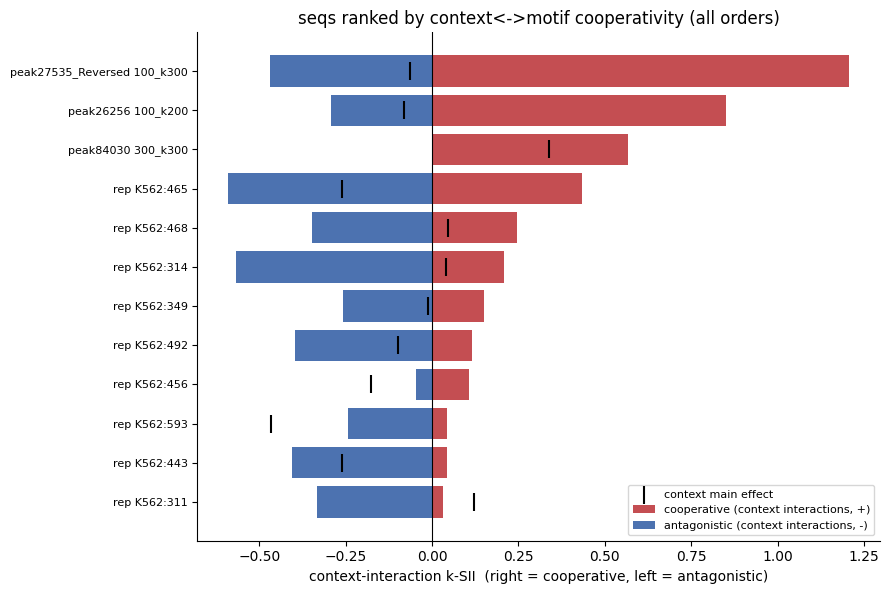

In [7]:
# PLOT 5 — context cooperativity vs antagonism, ranked. Split the context-containing INTERACTION terms
# (order>=2, any k) by sign: red-right = cooperative (sum of +k-SII), blue-left = antagonistic (sum of -k-SII).
# so bar length to the right literally = how much context cooperates with motifs. black tick = context main effect.
coop = []
for i in seqs:
    sii, spans, pn = results[i]
    ci = len(pn) - 1
    ints = [v for k, v in sii.dict_values.items() if ci in k and len(k) >= 2]
    pos = sum(v for v in ints if v > 0)
    neg = sum(v for v in ints if v < 0)                            # negative
    main = sii.dict_values.get((ci,), 0.0)                         # context standalone (order 1)
    coop.append((names[i], pos, neg, main))
coop.sort(key=lambda r: r[1])

y = np.arange(len(coop))
fig, ax = plt.subplots(figsize=(9, 0.42 * len(coop) + 1))
ax.barh(y, [r[1] for r in coop], color="#c44e52", label="cooperative (context interactions, +)")
ax.barh(y, [r[2] for r in coop], color="#4c72b0", label="antagonistic (context interactions, -)")
ax.scatter([r[3] for r in coop], y, color="k", marker="|", s=180, zorder=5, label="context main effect")
ax.axvline(0, color="k", lw=0.8)
ax.set_yticks(y); ax.set_yticklabels([r[0] for r in coop], fontsize=8)
ax.set_xlabel("context-interaction k-SII  (right = cooperative, left = antagonistic)")
ax.set_title("seqs ranked by context<->motif cooperativity (all orders)")
ax.legend(fontsize=8, loc="lower right"); ax.spines[["top", "right"]].set_visible(False); plt.tight_layout()

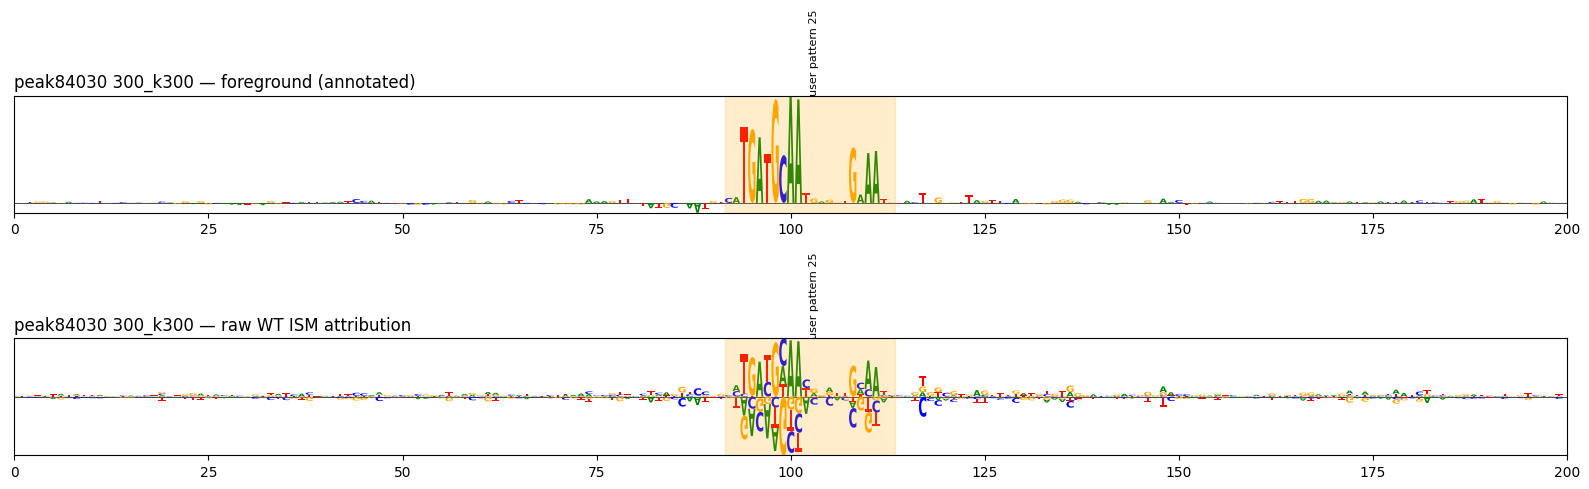

In [14]:
# visualize the top-cooperativity seq (peak27535): foreground + raw WT ISM attribution, motifs annotated.
# look OUTSIDE the orange motif spans for a context feature (attribution bump) that could be synergizing.
import logomaker, h5py
SEL2 = next(i for i in seqs if str(names[i]).startswith("peak84030"))
aw_idx = list(Z["motifko_idx"])
attr = Z["attr_wt"][aw_idx.index(SEL2)]                          # (200,4) mean-centered WT ISM (hypothetical)
with h5py.File(SIT / "mcs_k562/attr.h5") as f:
    fg = f["attr"][high.index(SEL2)].T                          # (200,4) projected foreground (annotated)

fig, axes = plt.subplots(2, 1, figsize=(16, 5))
for ax, (ttl, mat) in zip(axes, [("foreground (annotated)", fg), ("raw WT ISM attribution", attr)]):
    logomaker.Logo(pd.DataFrame(mat, columns=list("ACGT")), ax=ax)
    for s, e, m in motifs[SEL2]:                                 # motif spans -> var-region coords
        ax.axvspan(s - ADAPTER - 0.5, e - ADAPTER - 0.5, color="orange", alpha=0.2)
        ax.text((s + e) / 2 - ADAPTER, ax.get_ylim()[1], m, ha="center", va="bottom", fontsize=8, rotation=90)
    ax.set_title(f"{names[SEL2]} — {ttl}", loc="left"); ax.set_yticks([]); ax.set_xlim(0, 200)
fig.tight_layout()

target term: [user pattern 25] + context   full-context k-SII = +0.566
  win   0:50   [user pattern 25]+ctx k-SII = -0.044
  win   1:51   [user pattern 25]+ctx k-SII = -0.083
  win   2:52   [user pattern 25]+ctx k-SII = -0.110
  win   3:53   [user pattern 25]+ctx k-SII = -0.154
  win   4:54   [user pattern 25]+ctx k-SII = -0.190
  win   5:55   [user pattern 25]+ctx k-SII = -0.193
  win   6:56   [user pattern 25]+ctx k-SII = -0.212
  win   7:57   [user pattern 25]+ctx k-SII = -0.197
  win   8:58   [user pattern 25]+ctx k-SII = -0.202
  win   9:59   [user pattern 25]+ctx k-SII = -0.173
  win  10:60   [user pattern 25]+ctx k-SII = -0.156
  win  11:61   [user pattern 25]+ctx k-SII = -0.178
  win  12:62   [user pattern 25]+ctx k-SII = -0.191
  win  13:63   [user pattern 25]+ctx k-SII = -0.178
  win  14:64   [user pattern 25]+ctx k-SII = -0.167
  win  15:65   [user pattern 25]+ctx k-SII = -0.137
  win  16:66   [user pattern 25]+ctx k-SII = -0.171
  win  17:67   [user pattern 25]+ctx k-SII = 

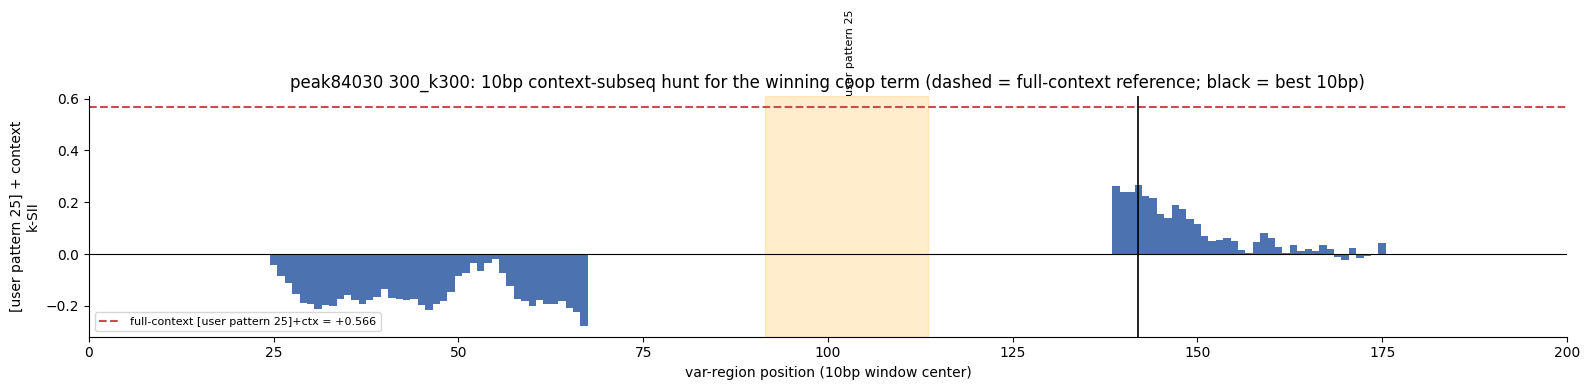

In [21]:
# SUBSEQ HUNT — localize the context feature behind the winning cooperativity term. For SEL_H we take the
# SAME target term PLOT 4 surfaced: the strongest positive k-SII among terms containing context (for
# peak27535 that's motif14 + motif16 + context). Then we slide a WIN=10bp window across the var region,
# make THAT window the context player (motifs unchanged), re-run the full-order k-SII game, and read off
# JUST that one target term's k-SII. The window whose value best matches the full-context reference is the
# ~10bp subseq that carries the context feature in that interaction. (~1-2 min on GPU.)
WIN = 50
STRIDE = 1
SEL_H = next(i for i in seqs if str(names[i]).startswith("peak84030"))   # top-coop seq; change as needed

sii0, spans, pn = results[SEL_H]
ci = len(pn) - 1
ctx_terms = [(k, v) for k, v in sii0.dict_values.items() if ci in k and len(k) >= 2]
tgt_key, tgt_val = max(ctx_terms, key=lambda kv: kv[1])                  # winning coop term (== PLOT 4)
tgt_motifs = tuple(sorted(j for j in tgt_key if j != ci))               # motif players in the target
tgt_label = " + ".join(pn[j] for j in tgt_motifs)
print(f"target term: [{tgt_label}] + context   full-context k-SII = {tgt_val:+.3f}")

wt = one_hot_encode(str(wt_str[SEL_H])).float()                          # (4,230)
shuf = dinucleotide_shuffle(wt.unsqueeze(0), n=N_REP, random_state=0)[0]  # (N_REP,4,230)
mmasks = [np.zeros(230, bool) for _ in spans]                           # one mask per motif player
for m, (s, e, _) in zip(mmasks, spans):
    m[s:e] = True
motif_any = np.zeros(230, bool)
for m in mmasks:
    motif_any |= m
m_ct = len(mmasks)                                                      # context = last player index
target = frozenset(tgt_motifs) | {m_ct}                                 # the term we read off each window

def target_ksii(ctx_mask):                                             # k-SII of the target term for this window
    players = mmasks + [ctx_mask]; n = len(players)
    coals = list(itertools.product([0, 1], repeat=n)); blocks = []
    for coal in coals:
        x = wt.unsqueeze(0).repeat(N_REP, 1, 1).clone()
        for present, msk in zip(coal, players):
            if not present:
                x[:, :, msk] = shuf[:, :, msk]                          # KO absent player -> shuffle
        blocks.append(x)
    preds = score(torch.cat(blocks, 0)).reshape(len(coals), N_REP).mean(1)
    cval = {c: float(v) for c, v in zip(coals, preds)}
    game = PrecomputedGame(n, cval[tuple([0] * n)], cval)
    sii = shapiq.ExactComputer(n_players=n, game=game)(index="k-SII", order=n)
    return next((v for k, v in sii.dict_values.items() if frozenset(k) == target), 0.0)

# slide the 10bp window across the var region (context positions only) as a stand-in context player
starts = [st for st in range(ADAPTER, ADAPTER + 200 - WIN + 1, STRIDE)
          if not motif_any[st:st + WIN].any()]
val = []
for st in starts:
    win = np.zeros(230, bool); win[st:st + WIN] = True
    val.append(target_ksii(win))
    print(f"  win {st - ADAPTER:>3}:{st - ADAPTER + WIN:<3}  [{tgt_label}]+ctx k-SII = {val[-1]:+.3f}")
val = np.array(val)
centers = np.array(starts) - ADAPTER + WIN / 2
bi = int(np.argmax(val))                                                # window best reproducing the coop term
print(f"\nBEST 10bp: {starts[bi] - ADAPTER}:{starts[bi] - ADAPTER + WIN}  "
      f"k-SII={val[bi]:+.3f} vs full-context {tgt_val:+.3f} ({val[bi] / tgt_val:.0%})")

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(centers, val, width=STRIDE, color="#4c72b0")
ax.axhline(tgt_val, color="#c44e52", ls="--", lw=1.5, label=f"full-context [{tgt_label}]+ctx = {tgt_val:+.3f}")
ax.axhline(0, color="k", lw=0.8)
for s, e, m in spans:
    ax.axvspan(s - ADAPTER - 0.5, e - ADAPTER - 0.5, color="orange", alpha=0.2)         # motif spans
    ax.text((s + e) / 2 - ADAPTER, ax.get_ylim()[1], m, ha="center", va="bottom", fontsize=8, rotation=90)
ax.axvline(centers[bi], color="k", lw=1.2)                                              # best window
ax.set_xlim(0, 200); ax.set_xlabel("var-region position (10bp window center)")
ax.set_ylabel(f"[{tgt_label}] + context\nk-SII")
ax.set_title(f"{names[SEL_H]}: 10bp context-subseq hunt for the winning coop term "
             f"(dashed = full-context reference; black = best 10bp)")
ax.legend(fontsize=8); ax.spines[["top", "right"]].set_visible(False); plt.tight_layout()

donor WT (high)=1.795  low WT mean=-1.210
  full ctx KO      0.845 ± 0.412
  feature KO       1.340 ± 0.258
  high->low        0.807 ± 0.526
  high+feat->low   1.482 ± 0.366
  rescue: high+feat->low recovers 68% of the high->low gap to donor WT


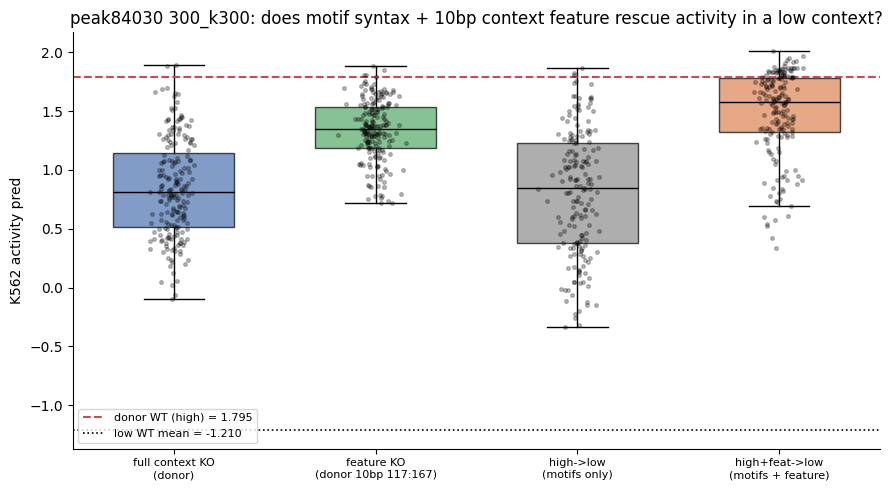

In [22]:
# BOX PLOT — activity rescue test (K562 pred). Donor = SEL_H (peak27535, high). Four conditions:
#   1) full context KO   — SEL_H, entire context dinuc-shuffled (motifs kept)        -> is context necessary?
#   2) feature KO        — SEL_H, only the best 10bp feature shuffled
#   3) high->low         — donor SEL_H motifs injected into each LOW target's context (Z["chimera"])  -> stays low
#   4) high+feat->low    — same chimeras but ALSO paste donor's 10bp feature into the low context      -> rescue?
# hypothesis: motif syntax alone (3) stays low; adding the context feature (4) pulls activity back to donor WT.
# needs the SUBSEQ HUNT cell above run first (uses SEL_H, wt, ADAPTER, WIN, motif_any, starts, bi).
N_BOX = 200
best_start = starts[bi]
feat = np.zeros(230, bool); feat[best_start:best_start + WIN] = True                 # best 10bp feature
ctx_full = np.zeros(230, bool); ctx_full[ADAPTER:ADAPTER + 200] = True; ctx_full &= ~motif_any

# 1,2 — KO on the donor itself (dinuc shuffle over N_BOX reps)
shufB = dinucleotide_shuffle(wt.unsqueeze(0), n=N_BOX, random_state=1)[0]            # (N_BOX,4,230)
def ko_preds(mask):
    x = wt.unsqueeze(0).repeat(N_BOX, 1, 1).clone(); x[:, :, mask] = shufB[:, :, mask]
    return score(x)
p_ctxko, p_featko = ko_preds(ctx_full), ko_preds(feat)

# 3,4 — chimeras: donor SEL_H motifs -> each low target's context (20 context-shuffle reps per pair)
cdon, ctgt, chim = Z["chimera_donor"], Z["chimera_target"], Z["chimera"]
pairs = np.where((cdon == SEL_H) & np.isin(ctgt, low))[0]
donor_feat = str(wt_str[SEL_H])[best_start:best_start + WIN]                         # donor bases in the feature window
def ohe_score(strs):
    return score(torch.stack([one_hot_encode(s).float() for s in strs]))
hl_strs = [str(chim[k, r]) for k in pairs for r in range(chim.shape[1])]             # high->low (motifs only)
hlf_strs = [s[:best_start] + donor_feat + s[best_start + WIN:] for s in hl_strs]     # + donor feature pasted in
p_hl, p_hlf = ohe_score(hl_strs), ohe_score(hlf_strs)

wt_hi = float(score(wt.unsqueeze(0))[0])                                             # donor WT (high)
wt_lo = float(ohe_score([str(wt_str[i]) for i in low]).mean())                       # mean low-target WT (low)
print(f"donor WT (high)={wt_hi:.3f}  low WT mean={wt_lo:.3f}")
for lab, p in [("full ctx KO", p_ctxko), ("feature KO", p_featko),
               ("high->low", p_hl), ("high+feat->low", p_hlf)]:
    print(f"  {lab:<16} {p.mean():.3f} ± {p.std():.3f}")
print(f"  rescue: high+feat->low recovers "
      f"{(p_hlf.mean() - p_hl.mean()) / (wt_hi - p_hl.mean()):.0%} of the high->low gap to donor WT")

data = [p_ctxko, p_featko, p_hl, p_hlf]
labels = ["full context KO\n(donor)", f"feature KO\n(donor 10bp {best_start - ADAPTER}:{best_start - ADAPTER + WIN})",
          "high->low\n(motifs only)", "high+feat->low\n(motifs + feature)"]
colors = ["#4c72b0", "#55a868", "#8c8c8c", "#dd8452"]
fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data, patch_artist=True, widths=0.6, showfliers=False)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
for med in bp["medians"]:
    med.set_color("k")
rng = np.random.default_rng(0)
for j, p in enumerate(data, 1):                                                     # jittered points
    ax.scatter(rng.normal(j, 0.05, len(p)), p, s=7, color="k", alpha=0.25, zorder=3)
ax.axhline(wt_hi, color="#c44e52", ls="--", lw=1.5, label=f"donor WT (high) = {wt_hi:.3f}")
ax.axhline(wt_lo, color="k", ls=":", lw=1.2, label=f"low WT mean = {wt_lo:.3f}")
ax.set_xticks([1, 2, 3, 4]); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("K562 activity pred")
ax.set_title(f"{names[SEL_H]}: does motif syntax + 10bp context feature rescue activity in a low context?")
ax.legend(fontsize=8); ax.spines[["top", "right"]].set_visible(False); plt.tight_layout()